# Options pricing, the volatility smile, and tail risk

Two themes the role cares about, tied together by one idea — that **real return distributions have fat tails**, and any model that assumes Gaussian thin tails will mis-price exactly the events that matter:

1. **Options** — Black-Scholes Greeks, then inverting live market quotes to implied vol and seeing the *smile* the market actually prices.
2. **Risk** — VaR/Expected Shortfall three ways, and why the Gaussian one lies to you.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})
from quantlab.options.black_scholes import BlackScholes as BS, OptionType, implied_volatility

## 1. Greeks across moneyness

The Greeks are the sensitivities a desk hedges. A quick sanity-and-intuition plot: delta sweeping 0→1 through the strike, and gamma/vega peaking at-the-money (where optionality is greatest). All derived analytically in `quantlab.options.black_scholes` — I checked them against finite differences in the test suite.

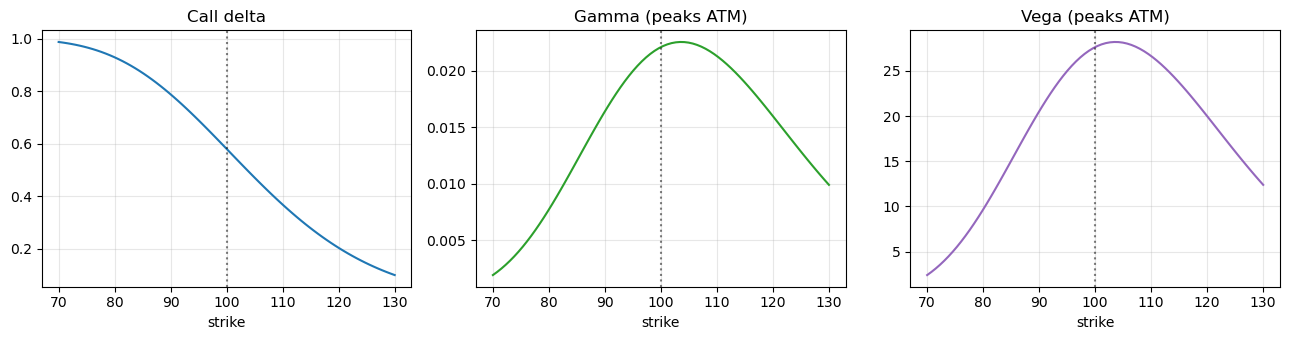

In [2]:
S, T, r, sigma = 100, 0.5, 0.04, 0.25
strikes = np.linspace(70, 130, 80)
g = [BS.greeks(S, K, T, r, sigma, option_type=OptionType.CALL) for K in strikes]
delta = [x.delta for x in g]; gamma = [x.gamma for x in g]; vega = [x.vega for x in g]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].plot(strikes, delta); ax[0].set(title='Call delta', xlabel='strike')
ax[1].plot(strikes, gamma, color='tab:green'); ax[1].set(title='Gamma (peaks ATM)', xlabel='strike')
ax[2].plot(strikes, vega, color='tab:purple'); ax[2].set(title='Vega (peaks ATM)', xlabel='strike')
for a in ax: a.axvline(S, color='k', ls=':', alpha=0.5)
plt.tight_layout()

## 2. The volatility smile, from a live option chain

Black-Scholes assumes a single, flat volatility. The market disagrees: invert real option prices to implied vol and you get a **smile/skew** — out-of-the-money options trade richer than a flat-vol model says, because the market prices in crashes and jumps. This pulls a live SPY chain and inverts every quote with the Brent solver. *(Needs network; if it fails, that's a data hiccup, not a code bug.)*

418 quotes inverted across 3 expiries


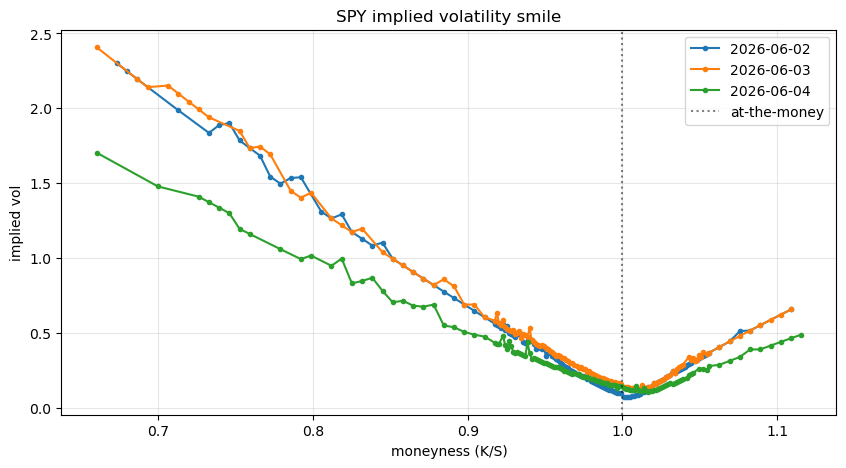

In [3]:
from quantlab.options.vol_surface import fetch_chain, build_iv_surface
chain = fetch_chain('SPY', max_expiries=3)
surface = build_iv_surface(chain, r=0.04)

fig, ax = plt.subplots(figsize=(10, 5))
for expiry, grp in surface.groupby('expiry'):
    grp = grp.sort_values('moneyness')
    ax.plot(grp['moneyness'], grp['implied_vol'], marker='o', ms=3, label=str(expiry.date()))
ax.axvline(1.0, color='k', ls=':', alpha=0.5, label='at-the-money')
ax.set(title='SPY implied volatility smile', xlabel='moneyness (K/S)', ylabel='implied vol'); ax.legend()
print(f'{len(surface)} quotes inverted across {surface.expiry.nunique()} expiries')

The upward curve away from the money is the fat-tail premium, made visible. Now the same fat tails, from the risk side.

## 3. Volatility clustering (GARCH)

Volatility isn't constant — it clusters. A GARCH(1,1) with Student-t innovations captures both the clustering and the fat tails of the innovations. The persistence α+β near 1 is the fingerprint of slowly-decaying vol.

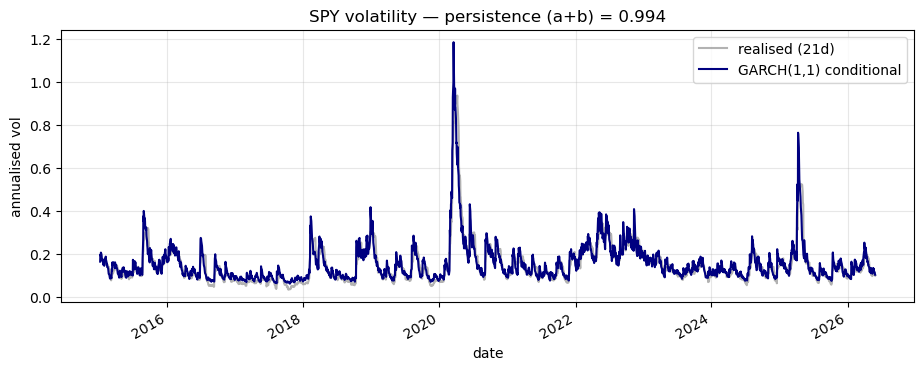

In [4]:
from quantlab.data.database import MarketDB
from quantlab.models.timeseries import fit_garch
from quantlab.utils import log_returns

spy = MarketDB.from_config().load_prices(['SPY'], field='adj_close')['SPY']
ret = log_returns(spy)
garch = fit_garch(ret)
cond_vol = pd.Series(garch.conditional_volatility, index=ret.index[-len(garch.conditional_volatility):]) * np.sqrt(252) / 100
realised = ret.rolling(21).std() * np.sqrt(252)

realised.plot(color='grey', alpha=0.6, label='realised (21d)')
cond_vol.plot(color='navy', label='GARCH(1,1) conditional')
plt.legend(); plt.title(f'SPY volatility — persistence (a+b) = {garch.params["alpha[1]"]+garch.params["beta[1]"]:.3f}'); plt.ylabel('annualised vol');

## 4. Value-at-Risk: why the Gaussian assumption is dangerous

VaR is the loss you don't expect to exceed with a given confidence; Expected Shortfall is the *average* loss when you do. I compute VaR three ways and overlay them on the actual return histogram. The Gaussian (parametric) VaR sits notably *inside* the historical and Student-t numbers — it systematically understates tail risk, precisely where understating it is most expensive.

Historical               3.23%
Parametric (Gaussian)    2.54%
Monte Carlo (t)          3.08%
Expected Shortfall       4.76%
dtype: object


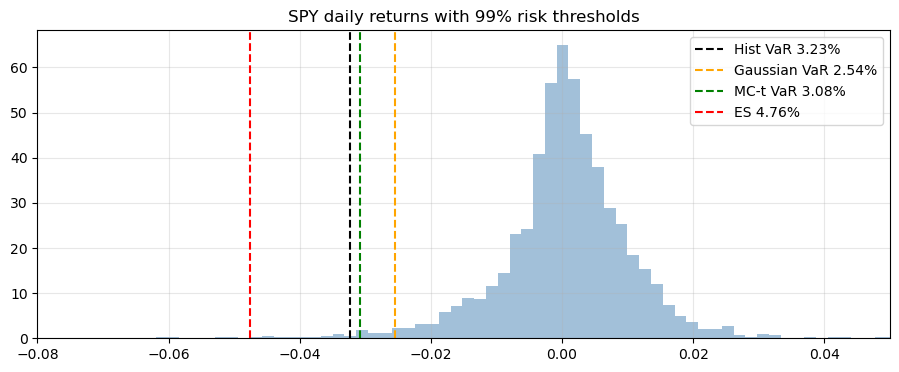

In [5]:
from quantlab.risk.metrics import historical_var, parametric_var, monte_carlo_var, expected_shortfall
conf = 0.99
hv, pv, mv = historical_var(ret, conf), parametric_var(ret, conf), monte_carlo_var(ret, conf)
es = expected_shortfall(ret, conf)
print(pd.Series({'Historical': hv, 'Parametric (Gaussian)': pv, 'Monte Carlo (t)': mv, 'Expected Shortfall': es}).map('{:.2%}'.format))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(ret, bins=120, color='steelblue', alpha=0.5, density=True)
for val, c, lab in [(-hv,'k','Hist VaR'), (-pv,'orange','Gaussian VaR'), (-mv,'green','MC-t VaR'), (-es,'red','ES')]:
    ax.axvline(val, color=c, ls='--', label=f'{lab} {abs(val):.2%}')
ax.set(title=f'SPY daily returns with {conf:.0%} risk thresholds', xlim=(-0.08, 0.05)); ax.legend()

## Takeaways

- The **smile** (from live quotes) and the **Gaussian-vs-empirical VaR gap** are two views of the same fact: returns have fatter tails than a normal model admits.
- That's why this repo prefers a **Student-t** for both the GARCH innovations and the Monte-Carlo VaR, and reports **Expected Shortfall** as the headline risk number — it's coherent (sub-additive) and it tells you how bad the bad days actually are.
- The same pricer powers `quantlab.options` end-to-end: price → Greeks → invert to IV → build the surface, all validated against put-call parity and finite-difference Greeks in the test suite.